Number of images: 278
Image shape: (64, 64)


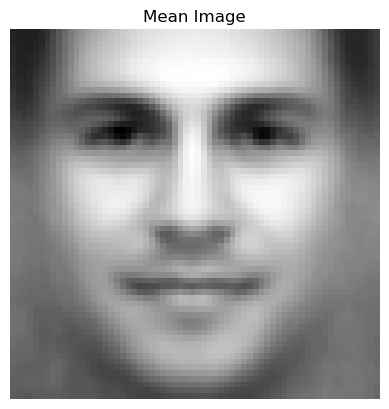

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

folder = "subset_300_white_men_20_35"

if not os.path.isdir(folder):
    raise FileNotFoundError(f"Image folder not found: {folder}")

images = []
image_names = []
expected_shape = None

for filename in sorted(os.listdir(folder)):
    if filename.lower().endswith((".png", ".jpg", ".jpeg")):
        path = os.path.join(folder, filename)

        img = Image.open(path).convert("L")
        img = np.array(img, dtype=float)

        if expected_shape is None:
            expected_shape = img.shape
        elif img.shape != expected_shape:
            raise ValueError(
                f"Image '{filename}' has shape {img.shape}, "
                f"expected {expected_shape}. All images must be the same size."
            )

        images.append(img)
        image_names.append(filename)

images = np.array(images)

mean_image = np.mean(images, axis=0)

print("Number of images:", len(images))
print("Image shape:", mean_image.shape)

plt.imshow(mean_image, cmap="gray")
plt.axis("off")
plt.title("Mean Image")
plt.show()

In [2]:
from sklearn.decomposition import PCA

# NOTE: PCA is fit on all images up front, before the later train/test CV
# splits used for rating prediction. This is standard for eigenface
# visualization, but means the PC basis (and therefore every PC score used
# as a regression feature later) was informed by images that end up in a
# CV test fold -- a mild form of leakage for the R² estimates below. A
# fully leakage-free pipeline would refit PCA inside each CV fold. Left as
# global PCA here since the primary goal is eigenface visualization and
# qualitative face synthesis, not a publishable unbiased R².
centered_images = images - mean_image

n_images, height, width = centered_images.shape
X = centered_images.reshape(n_images, height * width)

pca = PCA()
X_pca = pca.fit_transform(X)

print("PCA shape:", X_pca.shape)

PCA shape: (278, 278)


In [3]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(n_components)

87


In [4]:
first_5 = pca.explained_variance_ratio_[:5]

print("Explained variance by first 5 PCs:")
for i, value in enumerate(first_5, start=1):
    print(f"PC{i}: {value * 100:.2f}%")

print(f"Total explained by first 5 PCs: {first_5.sum() * 100:.2f}%")

Explained variance by first 5 PCs:
PC1: 23.50%
PC2: 15.53%
PC3: 10.93%
PC4: 5.68%
PC5: 4.18%
Total explained by first 5 PCs: 59.83%


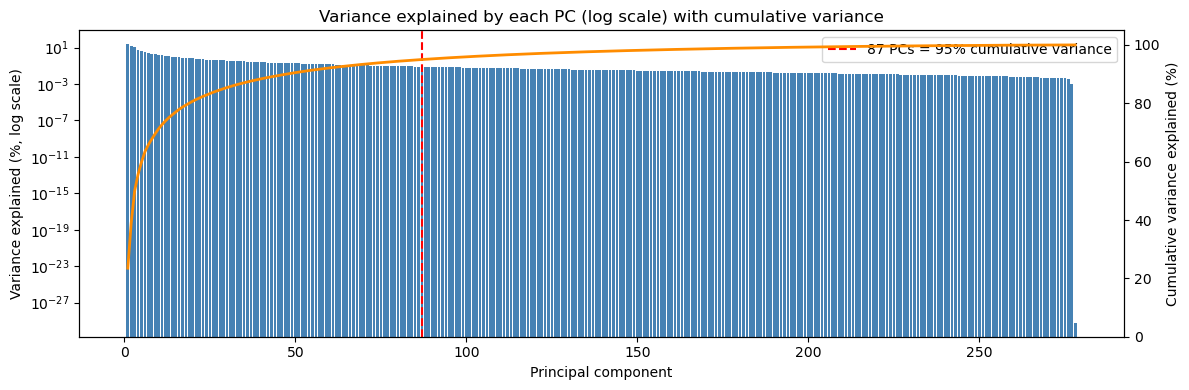

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 4))

pc_numbers = np.arange(1, len(pca.explained_variance_ratio_) + 1)
ax1.bar(pc_numbers, pca.explained_variance_ratio_ * 100, color="steelblue")
ax1.set_yscale("log")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Variance explained (%, log scale)")

ax2 = ax1.twinx()
ax2.plot(pc_numbers, cumulative_variance * 100, color="darkorange", linewidth=2)
ax2.set_ylabel("Cumulative variance explained (%)")
ax2.set_ylim(0, 105)

ax1.axvline(n_components, color="red", linestyle="--",
            label=f"{n_components} PCs = 95% cumulative variance")
ax1.legend(loc="upper right")

plt.title("Variance explained by each PC (log scale) with cumulative variance")
plt.tight_layout()
plt.show()

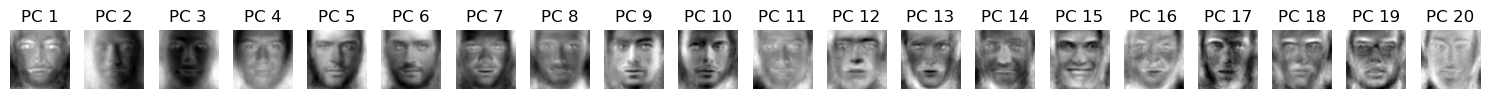

In [6]:
fig, axes = plt.subplots(1, 20, figsize=(15, 3))

for i in range(20):
    pc_image = pca.components_[i].reshape(height, width)
    axes[i].imshow(pc_image, cmap="gray")
    axes[i].set_title(f"PC {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

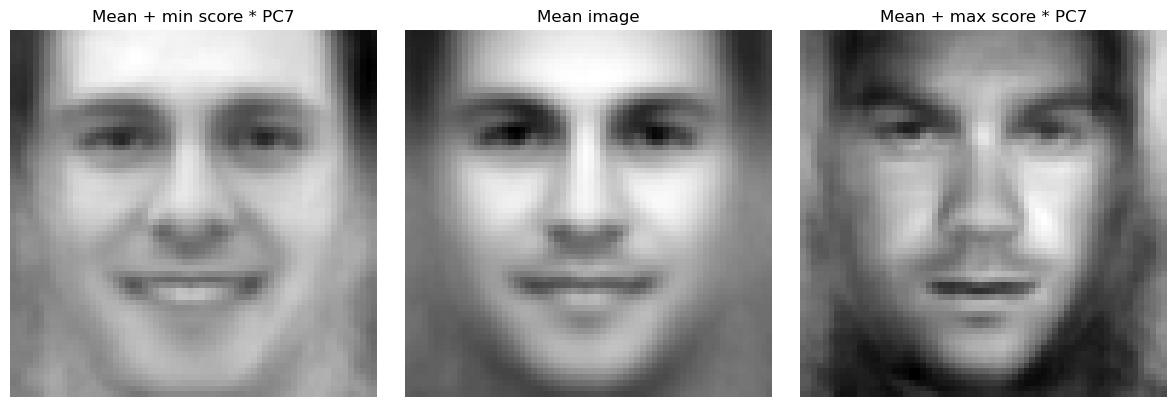

In [7]:
pc_index = 6  # 0 = PC1, 1 = PC2, etc.

pc = pca.components_[pc_index].reshape(height, width)
scores = X_pca[:, pc_index]

min_score = np.min(scores)
max_score = np.max(scores)

img_min = mean_image + min_score * pc
img_mean = mean_image
img_max = mean_image + max_score * pc

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_min, cmap="gray")
axes[0].set_title(f"Mean + min score * PC{pc_index+1}")
axes[0].axis("off")

axes[1].imshow(img_mean, cmap="gray")
axes[1].set_title("Mean image")
axes[1].axis("off")

axes[2].imshow(img_max, cmap="gray")
axes[2].set_title(f"Mean + max score * PC{pc_index+1}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_score

ratings_path = "average_ratings.csv"
if not os.path.isfile(ratings_path):
    raise FileNotFoundError(f"Ratings file not found: {ratings_path}")

df = pd.read_csv(ratings_path)

# Only keep the first PCs explaining at least 95%
X_selected = X_pca[:, :n_components]

# PCA scores + corresponding image names
pc_df = pd.DataFrame(X_selected)
pc_df["Images"] = image_names

# One average rating per image already, so no stacking/duplication needed
# (this also removes the earlier pseudo-replication concern from having two
# rating columns per image).
ratings_df = df[["Images", "average_rating"]].rename(columns={"average_rating": "Rating"})

# Match ratings to the correct PCA image
data = ratings_df.merge(pc_df, on="Images")

# Remove missing ratings
data = data.dropna(subset=["Rating"])

# Make X, y and groups
X = data.drop(columns=["Images", "Rating"]).to_numpy()
y = data["Rating"].to_numpy()
groups = data["Images"].to_numpy()

print("X:", X.shape)
print("y:", y.shape)

# Linear regression model
model = LinearRegression()

# Cross-validation
group_cv = GroupKFold(n_splits=5)
cv_splits = list(group_cv.split(X, y, groups))

X: (256, 87)
y: (256,)


In [9]:
# Manual greedy forward selection.
#
# The previous version called SequentialFeatureSelector fresh for every k from
# 1..n_components. Since forward selection is nested (the winning set for k
# always contains the winning set for k-1), that re-derived the same earlier
# choices from scratch each time -- O(K) SFS calls, each itself doing O(K)
# rounds, each round scoring O(n_features) candidates: O(K^2 * n_features)
# candidate evaluations in total, most of them repeated work.
#
# This version keeps a running `selected` list and only evaluates the
# remaining candidate features at each step, so each feature is scored once
# per round: O(K * n_features) candidate evaluations overall, with identical
# results since both implementations use the same greedy forward criterion.

selected = []
remaining = list(range(n_components))
selection_order = []
previous_score = -np.inf
best_selected = None

for k in range(1, n_components + 1):

    best_score = -np.inf
    best_feature = None

    for feature in remaining:
        candidate = selected + [feature]
        score = cross_val_score(
            model,
            X[:, candidate],
            y,
            cv=cv_splits,
            scoring="r2"
        ).mean()

        if score > best_score:
            best_score = score
            best_feature = feature

    change = best_score - previous_score

    if best_score <= previous_score:
        print("\nNo improvement. Stopping.")
        break

    selected.append(best_feature)
    remaining.remove(best_feature)
    selection_order.append(best_feature + 1)
    previous_score = best_score
    best_selected = np.array(selected)

    print(
        f"{k} PCs: {selection_order}   "
        f"R² = {best_score:.4f}   "
        f"Change = {change:+.4f}"
    )

print("\nPCs picked in order:", selection_order)
print("Best CV R²:", round(previous_score, 4))

1 PCs: [6]   R² = 0.0357   Change = +inf
2 PCs: [6, 7]   R² = 0.0746   Change = +0.0389
3 PCs: [6, 7, 58]   R² = 0.1090   Change = +0.0344
4 PCs: [6, 7, 58, 55]   R² = 0.1422   Change = +0.0332
5 PCs: [6, 7, 58, 55, 45]   R² = 0.1686   Change = +0.0264
6 PCs: [6, 7, 58, 55, 45, 21]   R² = 0.1955   Change = +0.0270
7 PCs: [6, 7, 58, 55, 45, 21, 11]   R² = 0.2262   Change = +0.0307
8 PCs: [6, 7, 58, 55, 45, 21, 11, 10]   R² = 0.2485   Change = +0.0222
9 PCs: [6, 7, 58, 55, 45, 21, 11, 10, 48]   R² = 0.2670   Change = +0.0185
10 PCs: [6, 7, 58, 55, 45, 21, 11, 10, 48, 82]   R² = 0.2805   Change = +0.0135
11 PCs: [6, 7, 58, 55, 45, 21, 11, 10, 48, 82, 13]   R² = 0.2935   Change = +0.0130
12 PCs: [6, 7, 58, 55, 45, 21, 11, 10, 48, 82, 13, 20]   R² = 0.3039   Change = +0.0104
13 PCs: [6, 7, 58, 55, 45, 21, 11, 10, 48, 82, 13, 20, 19]   R² = 0.3147   Change = +0.0108
14 PCs: [6, 7, 58, 55, 45, 21, 11, 10, 48, 82, 13, 20, 19, 76]   R² = 0.3245   Change = +0.0098
15 PCs: [6, 7, 58, 55, 45, 21, 

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Fit final model using the PCs selected by forward selection
final_model = LinearRegression()
final_model.fit(X[:, best_selected], y)

beta = final_model.coef_
intercept = final_model.intercept_


def generate_face(rating):

    # Find PC scores that give the requested rating.
    # NOTE: beta . x = rating - intercept has infinitely many solutions x
    # (any point on that hyperplane in PC-score space works). This picks the
    # minimum-norm solution, i.e. it moves only along the beta direction and
    # leaves every direction orthogonal to beta at zero. That makes it the
    # "shortest path from the mean face to the target rating" rather than a
    # typical/representative face at that rating -- useful for visualizing
    # the rating-predictive direction, but not a sample from the rating's
    # actual face distribution.
    pc_scores = ((rating - intercept) / np.sum(beta**2)) * beta

    # Start from the average face
    face = mean_image.flatten().copy()

    # Add the selected PCs with their calculated scores
    for score, pc_index in zip(pc_scores, best_selected):
        face += score * pca.components_[pc_index]

    # Turn back into an image
    face = face.reshape(height, width)

    # Keep pixel values valid
    face = np.clip(face, 0, 255)

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(face, cmap="gray")
    plt.title(f"Synthetic face — Rating {rating}")
    plt.axis("off")
    plt.show()

    return face

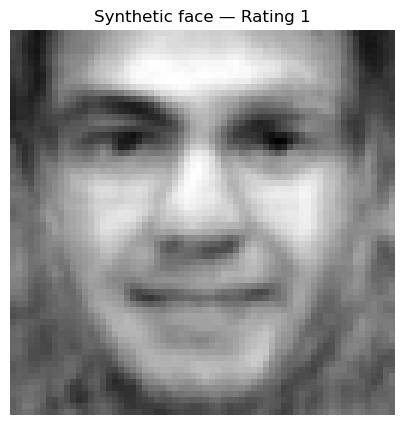

array([[ 92.83650075,  91.30917431,  84.83419823, ...,  76.88501143,
         79.25422053,  85.57770108],
       [ 95.41817728,  91.26236663,  82.35763297, ...,  77.27569634,
         80.5063558 ,  85.22332036],
       [ 93.89039913,  89.97915908,  80.01414359, ...,  76.38262632,
         82.07330063,  84.24456484],
       ...,
       [106.41596624, 110.32003315, 115.75224496, ..., 110.58504706,
        110.15597675, 111.62044607],
       [106.77128198, 111.80731271, 119.22418633, ..., 113.78560845,
        113.09040296, 110.47244111],
       [109.01794738, 111.9938222 , 114.93625817, ..., 115.18905546,
        115.03041023, 110.45384497]])

In [11]:
generate_face(1)

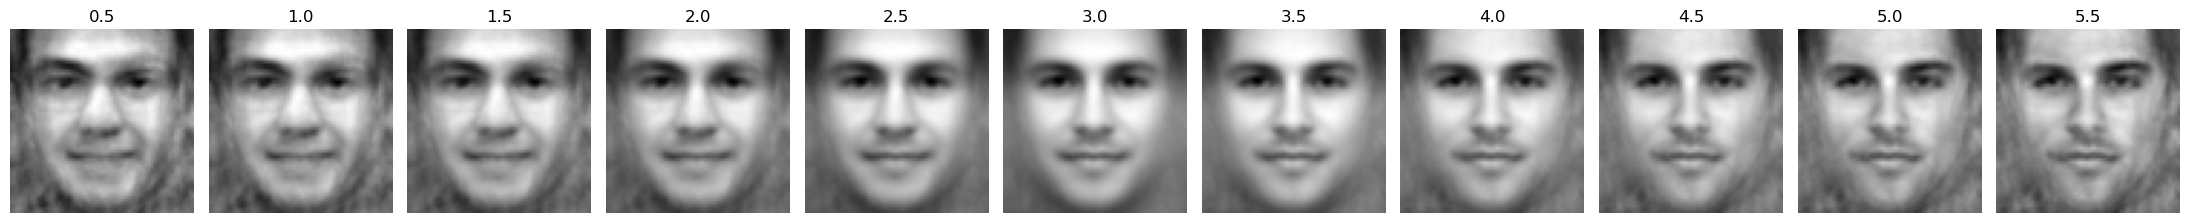

In [12]:
ratings = np.arange(0.5, 5.5 + 0.5, 0.5)

fig, axes = plt.subplots(1, len(ratings), figsize=(22, 4))

for ax, rating in zip(axes, ratings):
    # Find PC scores that give the requested rating
    pc_scores = ((rating - intercept) / np.sum(beta**2)) * beta

    # Start from the average face
    face = mean_image.flatten().copy()

    # Add the selected PCs
    for score, pc_index in zip(pc_scores, best_selected):
        face += score * pca.components_[pc_index]

    # Reshape back to image
    face = face.reshape(height, width)
    face = np.clip(face, 0, 255)

    ax.imshow(face, cmap="gray")
    ax.set_title(f"{rating}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Leakage-free R² estimate (nested cross-validation)

Everything above uses a single PCA basis fit on *all* images, so the reported
CV R² is a mild overestimate: the eigenfaces were partly shaped by images
that later act as "held-out" test data.

This section re-estimates R² properly: for each of the 5 outer folds, PCA is
refit using *only* that fold's training images, and forward selection is run
with its own inner cross-validation, entirely on training data. The test
fold's images are projected onto that fold's PCA basis (never used to fit
it) before scoring. This does **not** replace the model used above for
`generate_face` — that final model is intentionally trained on all the data
to make the best use of it for generating synthetic faces. This section only
produces an unbiased estimate of how well the *approach* generalizes.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Raw (uncentered) pixel arrays for exactly the images that survived the
# rating merge, in the same row order as `data` / `y` / `groups` above.
raw_image_lookup = dict(zip(image_names, images))
raw_images_matched = np.stack([raw_image_lookup[name] for name in data["Images"]])


def fit_fold_pca(train_images, variance_threshold=0.95):
    train_mean = train_images.mean(axis=0)
    n, h, w = train_images.shape
    centered = (train_images - train_mean).reshape(n, h * w)

    pca_fold = PCA()
    train_scores = pca_fold.fit_transform(centered)

    cumulative = np.cumsum(pca_fold.explained_variance_ratio_)
    k = np.argmax(cumulative >= variance_threshold) + 1

    return pca_fold, train_mean, train_scores[:, :k], k


def greedy_forward_selection(X, y, cv_splits, model):
    selected = []
    remaining = list(range(X.shape[1]))
    previous_score = -np.inf
    best_selected = []

    while remaining:
        best_score = -np.inf
        best_feature = None

        for feature in remaining:
            candidate = selected + [feature]
            score = cross_val_score(
                model, X[:, candidate], y, cv=cv_splits, scoring="r2"
            ).mean()

            if score > best_score:
                best_score = score
                best_feature = feature

        if best_score <= previous_score:
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        previous_score = best_score
        best_selected = list(selected)

    return best_selected, previous_score


outer_cv = GroupKFold(n_splits=5)
model = LinearRegression()
nested_r2_scores = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(raw_images_matched, y, groups), start=1
):
    train_images_fold = raw_images_matched[train_idx]
    test_images_fold = raw_images_matched[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # PCA fit on training images of this fold only
    pca_fold, train_mean, train_scores, k_fold = fit_fold_pca(train_images_fold)

    # Project the held-out test images onto this fold's PCA basis
    n_test, h, w = test_images_fold.shape
    test_centered = (test_images_fold - train_mean).reshape(n_test, h * w)
    test_scores = pca_fold.transform(test_centered)[:, :k_fold]

    # Forward selection with its own inner CV, using only training data
    inner_cv = list(KFold(n_splits=4, shuffle=True, random_state=0).split(train_scores))
    selected, inner_r2 = greedy_forward_selection(train_scores, y_train, inner_cv, model)

    fold_model = LinearRegression()
    fold_model.fit(train_scores[:, selected], y_train)

    y_pred = fold_model.predict(test_scores[:, selected])
    fold_r2 = r2_score(y_test, y_pred)
    nested_r2_scores.append(fold_r2)

    print(
        f"Fold {fold}: PCA components={k_fold}, PCs selected={len(selected)}, "
        f"inner CV R²={inner_r2:.4f}, held-out test R²={fold_r2:.4f}"
    )

print("\nNested CV R² (leakage-free):", round(np.mean(nested_r2_scores), 4))
print("Original (leaky) CV R² from above:", round(previous_score, 4))